# Simulation

### Overview of simulation pipeline:

1. Read in steps from `edepsim` & preprocess for JAX/PyTorch (`JAXTPC/tools/loader.py`)
2. Compute light yield per step (incl. e.g. recombination). TODO
3. Simulate TOF for each photon given ($x$, $t_0$, $n_\text{photon}$). Now have set of {(pmt, $t$)}, just need response.
5. Sample scintillation & TPB response offsets $t_\text{scint}$ and $t_\text{TPB}$, compute {(pmt, $t+t_\text{scint}+t_\text{TPB}$)} (`waveforms/waveforms_module/make_waveform.py`)
6. Gather times & perform (stitched) convolution.

In [1]:
import os; os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
# init tof sampler
from sampler import TOFSampler
PLIB_PATH = "/sdf/data/neutrino/youngsam/compressed_plib_b04_quantile_log_n50.h5"
N_SIMULATED = 15_000_000  # 15M photons / voxel
tofsampler = TOFSampler(PLIB_PATH, n_simulated=N_SIMULATED, lazy=False, device="cuda:0", interpolate=True)

In [3]:
import sys; sys.path.insert(0, "/sdf/home/y/youngsam/sw/dune/sim/goop/jaxtpc")

In [4]:
# 1. Read in from edepsim
from tools.loader import ParticleStepExtractor, DepositData
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax.numpy as jnp

filepath = "/sdf/home/y/youngsam/sw/dune/sirentv/data/out.h5"
# filepath = "/sdf/data/neutrino/public_html/dc/mpvmpr_20.h5"
LIGHT_YIELD = 20000
ev_idx = 0

with ParticleStepExtractor(filepath, verbose=True) as extractor:
    step_data = extractor.extract_step_arrays(ev_idx)

# 2. Compute light yield per step
positions_mm = jnp.asarray(
        step_data.get('position', jnp.empty((0, 3))), dtype=jnp.float32
    )
n = positions_mm.shape[0]

deposit_data = DepositData(
    positions_mm=positions_mm,
    de=jnp.asarray(step_data.get('de', jnp.zeros((n,))), dtype=jnp.float32),
    dx=jnp.asarray(step_data.get('dx', jnp.zeros((n,))), dtype=jnp.float32),
    valid_mask=jnp.ones(n, dtype=bool),
    theta=jnp.asarray(step_data.get('theta', jnp.zeros((n,))), dtype=jnp.float32),
    phi=jnp.asarray(step_data.get('phi', jnp.zeros((n,))), dtype=jnp.float32),
    track_ids=jnp.asarray(step_data.get('track_id', jnp.ones((n,))), dtype=jnp.int32),
)

# Print summary
n_segments = deposit_data.positions_mm.shape[0]
n_tracks = len(jnp.unique(deposit_data.track_ids))
total_de = jnp.sum(deposit_data.de)

print(f"\nLoaded DepositData:")
print(f"  Segments: {n_segments:,}")
print(f"  Unique tracks: {n_tracks}")
print(f"  Total dE: {total_de:.2f} MeV")
print(f"\nFields:")
for field in deposit_data._fields:
    arr = getattr(deposit_data, field)
    print(f"  {field}: shape={arr.shape}, dtype={arr.dtype}")

Loaded file: /sdf/home/y/youngsam/sw/dune/sirentv/data/out.h5
Step path: pstep/lar_vol
Particle path: particle/geant4
Association path: ass/particle_pstep_lar_vol


E0316 17:37:24.810734   60205 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0316 17:37:24.810683   60204 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0316 17:37:24.810923   60206 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


Skipping string field: proc_name_start
Skipping string field: proc_name_end

Loaded DepositData:
  Segments: 226,796
  Unique tracks: 17722
  Total dE: 14850.17 MeV

Fields:
  positions_mm: shape=(226796, 3), dtype=float32
  de: shape=(226796,), dtype=float32
  dx: shape=(226796,), dtype=float32
  valid_mask: shape=(226796,), dtype=bool
  theta: shape=(226796,), dtype=float32
  phi: shape=(226796,), dtype=float32
  track_ids: shape=(226796,), dtype=int32


In [5]:
# 2. Compute light yield per step

LIGHT_YIELD = 20_000
# in the future, recombination will affect this.
photons_step = jnp.ceil(deposit_data.de * LIGHT_YIELD).astype(jnp.int32)

In [6]:
# now have a set of positions, num_photons, t_step!
#!TODO: DepositData does not include t_step of photons_step

# use dlpack to convert from jax array into pytorch
import torch.utils.dlpack

pos = torch.utils.dlpack.from_dlpack(deposit_data.positions_mm)
num_photons = torch.utils.dlpack.from_dlpack(photons_step)
t_step = torch.utils.dlpack.from_dlpack(step_data.get('t', jnp.zeros((n,))))
t_step -= t_step.min() # !!! TODO: remove

In [121]:
#  3. Simulate TOF for each photon given ($x$, $t_0$, $n_\text{photon}$) using PCA sampler
sampler_t, sampler_ch = tofsampler.sample(
    pos,
    num_photons,
    t_step=t_step,
    return_histogram=False,
) # on gpu
print(f"{sampler_t.shape[0]:,}, detected photons out of {num_photons.sum():,}")

11,069,447, detected photons out of 297,118,228


In [122]:
# 4. Simulate response
import torch

def scintillation_offset(n_photons, singlet_fraction=0.30, tau_s=1, tau_t=1530, device="cuda:0"):
    is_singlet = torch.rand((n_photons,), device=device) < singlet_fraction
    num_singlets = is_singlet.sum().item()
    singlet_delays = (
        torch.distributions.Exponential(1.0 / tau_s)
        .sample((num_singlets,))
        .to(device)
    ) # (n * p,)
    num_triplets = (~is_singlet).sum().item()
    triplet_delays = (
        torch.distributions.Exponential(1.0 / tau_t)
        .sample((num_triplets,))
        .to(device)
    ) # (n * (1-p),)
    delays = torch.cat([singlet_delays, triplet_delays]) # (n,)
    return delays

def tpb_delay(num_photons, tau=20, device="cuda:0"):
    """Just a simple 2ns exponential delay for now"""
    return torch.distributions.Exponential(1.0 / tau).sample((num_photons,)).to(device)

def pmt_tts(n_hits, tts_spread=1.0, device="cuda:0"):
    # FWHM to sigma conversion: FWHM = 2.35482 * sigma ==> sigma = FWHM / 2.35482
    sigma = tts_spread / 2.35482
    return torch.normal(mean=0.0, std=sigma, size=(n_hits,), device=device)

n_hits = sampler_t.shape[0]
sampler_t += scintillation_offset(n_hits, device="cuda:0")
sampler_t += tpb_delay(n_hits, device="cuda:0")
sampler_t += pmt_tts(n_hits, device="cuda:0")

In [123]:
# 5. Perform stitched convolution for RLC.

# basic idea:
# * sort array by time
# * find contiguous regions
# * remove dead space between regions
# * add enough padding so that that response tail is preserved
# * convolve each region
# * save final waveform + offsets


# We should find contiguous regions & add a constant padding offset to each of them
# and then combine those which were previously non-contiguous but now are
# with the new padding.
# then, we cut & combine, do conv, and save offsets.
# reconstructing will then just be a matter of adding the offsets to the original times.

In [138]:
# Steps 1-3: per-PMT sort, compress, histogram
device = sampler_t.device
tick_ns = 1

# SiPM impulse response physical constants (ns)
RESP_TIME_NS  = 55.0   # relaxation time
OSC_PERIOD_NS = 110.0   # oscillation period

# kernel_ns: time for |h(t)| to permanently drop below 0.1% of peak
_t = torch.arange(0, 20000, dtype=torch.float32, device=device)
_h = torch.exp(-_t / RESP_TIME_NS) * torch.sin(_t / OSC_PERIOD_NS)
_above = _h.abs() > 1e-3 * _h.abs().max()
kernel_ns = float(_t[_above].max().item()) + 1.0
del _t, _h, _above
print(f"kernel_ns (RLC baseline @ 1e-3): {kernel_ns:.0f} ns")

N_CHANNELS = int(sampler_ch.max().item()) + 1

per_pmt_histograms = []
per_pmt_segments = []
per_pmt_n_bins = []

for ch in range(N_CHANNELS):
    mask = (sampler_ch == ch)
    ch_times = sampler_t[mask]

    if ch_times.numel() == 0:
        per_pmt_histograms.append(torch.zeros(1, device=device))
        per_pmt_segments.append((torch.tensor([0], device=device),
                                 torch.tensor([0.0], device=device)))
        per_pmt_n_bins.append(1)
        continue

    sorted_t_ch = ch_times.sort().values
    diffs = torch.diff(sorted_t_ch)

    excess = (diffs - kernel_ns).clamp(min=0)
    cum_dead = torch.cat([torch.zeros(1, device=device), excess.cumsum(0)])
    compressed_t = sorted_t_ch - cum_dead - sorted_t_ch[0]

    n_bins = int(compressed_t[-1].item() / tick_ns) + 1
    bin_idx = (compressed_t / tick_ns).long().clamp(max=n_bins - 1)
    hist = torch.zeros(n_bins, device=device, dtype=torch.float32)
    hist.scatter_add_(0, bin_idx, torch.ones_like(bin_idx, dtype=torch.float32))

    per_pmt_histograms.append(hist)
    per_pmt_n_bins.append(n_bins)

    gap_mask = diffs > kernel_ns
    gap_indices = torch.where(gap_mask)[0]
    seg_comp_bins = [0]
    seg_real_times = [sorted_t_ch[0].item()]
    for g in gap_indices:
        seg_comp_bins.append(int(compressed_t[g + 1].item() / tick_ns))
        seg_real_times.append(sorted_t_ch[g + 1].item())
    per_pmt_segments.append((
        torch.tensor(seg_comp_bins, device=device),
        torch.tensor(seg_real_times, device=device),
    ))

# pad to max length and stack into (1, N_CHANNELS, max_bins)
max_bins = max(per_pmt_n_bins)
padded = [torch.nn.functional.pad(h, (0, max_bins - h.numel())) for h in per_pmt_histograms]
histograms = torch.stack(padded).unsqueeze(0)

total_bins_sum = sum(per_pmt_n_bins)
print(f"per-PMT compression: max_bins={max_bins}, sum(per_pmt_bins)={total_bins_sum}")
print(f"histograms shape: {histograms.shape}")

kernel_ns (RLC baseline @ 1e-3): 470 ns
per-PMT compression: max_bins=88240, sum(per_pmt_bins)=12606779
histograms shape: torch.Size([1, 162, 88240])


In [139]:
# per-PMT bin counts (diagnostic)
import numpy as np
bins_arr = np.array(per_pmt_n_bins)
active = bins_arr[bins_arr > 1]
print(f"active PMTs: {len(active)}/{N_CHANNELS}")
print(f"per-PMT bins — min: {active.min()}, median: {int(np.median(active))}, max: {active.max()}")

active PMTs: 162/162
per-PMT bins — min: 65441, median: 77295, max: 88240


In [140]:
# Step 4: FFT convolution with SiPM impulse response
import torch.nn.functional as F

# uses RESP_TIME_NS, OSC_PERIOD_NS defined in the compression cell
TICK_NS    = tick_ns
GAIN       = -45.0              # ADC·us/pe
KERNEL_DUR_NS = 9000.0          # ns — kernel window (LIGHT_WINDOW: [1,10])

# build impulse response kernel (all times in ns)
# note: normalization [1/ns] is made dimensionless by the fixed reference
# tick of 1 ns (matching the original GAIN calibration), NOT the variable tick_ns
conv_ticks = int(KERNEL_DUR_NS / TICK_NS)
tt = torch.arange(conv_ticks, device=device, dtype=torch.float32)
t_ns = tt * TICK_NS
kernel = (torch.exp(-t_ns / RESP_TIME_NS) * torch.sin(t_ns / OSC_PERIOD_NS)
          * (OSC_PERIOD_NS**2 + RESP_TIME_NS**2) / (OSC_PERIOD_NS * RESP_TIME_NS**2))

# FFT conv over all channels: histograms is (1, N_CHANNELS, max_bins)
ninput, ndet, ntick = histograms.shape
pad = conv_ticks - 1
padded = F.pad(histograms, (0, pad)).reshape(ninput * ndet, ntick + pad)
k_fft = torch.fft.rfft(kernel, n=ntick + pad)
waveforms = torch.fft.irfft(torch.fft.rfft(padded) * k_fft.unsqueeze(0), n=ntick + pad)
waveforms = GAIN * waveforms.reshape(ninput, ndet, -1)[:, :, :]

print(f"waveforms shape: {waveforms.shape}")

waveforms shape: torch.Size([1, 162, 97239])


In [141]:
# Step 5: per-PMT segment offset map (compressed bin -> real time)
# per_pmt_segments[ch] = (segment_starts_compressed_bin, segment_starts_real_time)
# already computed in step 1-3 cell above

def compressed_bin_to_real_time(ch, compressed_bin):
    seg_bins, seg_times = per_pmt_segments[ch]
    k = (seg_bins <= compressed_bin).nonzero()[-1].item()
    return seg_times[k].item() + (compressed_bin - seg_bins[k].item()) * tick_ns

n_segments_total = sum(s[0].numel() for s in per_pmt_segments)
print(f"total segments across all PMTs: {n_segments_total}")
print(f"waveforms shape: {waveforms.shape}")

total segments across all PMTs: 4861
waveforms shape: torch.Size([1, 162, 97239])


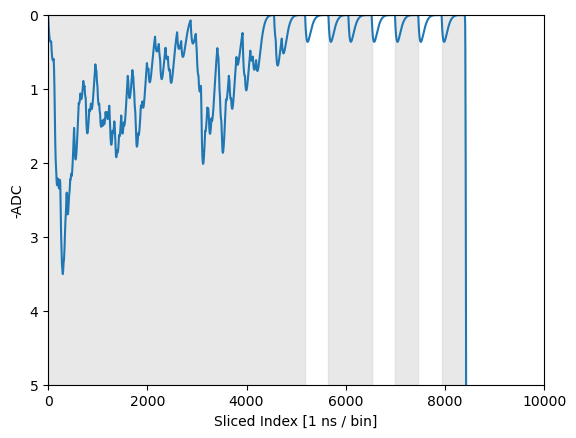

In [146]:
MAX_BINS = int(1e4)
starts_bin, starts_time = per_pmt_segments[0]
plt.plot(-waveforms[0,0,:MAX_BINS].detach().cpu())

# Shade regions: every other segment grey, in between white (no shade)
for i in range(starts_bin.numel()):
    seg_start = starts_bin[i].item()
    if i + 1 < starts_bin.numel():
        seg_end = starts_bin[i + 1].item()
    else:
        seg_end = MAX_BINS
    if seg_start >= MAX_BINS:
        break
    seg_end = min(seg_end, MAX_BINS)
    if i % 2 == 0:  # shade every other region
        plt.axvspan(seg_start, seg_end, color='lightgrey', alpha=0.5, zorder=0)
    # Optional: add vertical line for segment starts
    # plt.axvline(seg_start, color='k', linestyle='--', lw=0.5)

# plt.yscale('log')
plt.ylim(0, 5)
plt.xlim(0,MAX_BINS)
plt.gca().invert_yaxis()
plt.xlabel(f'Sliced Index [{TICK_NS} ns / bin]')
plt.ylabel('-ADC')
plt.show()

In [147]:
def decompress_waveform(ch):
    """Expand a compressed waveform back to the real time axis for one PMT.

    Returns (t0_ns, real_wf) where t0_ns is the real time of the first bin
    and real_wf is a 1D tensor on the real time axis (zeros in dead gaps).
    """
    seg_bins, seg_times = per_pmt_segments[ch]
    n_segs = seg_bins.numel()
    n_comp = per_pmt_n_bins[ch]

    # include convolution tail beyond last histogram bin
    eff_len = min(n_comp + conv_ticks - 1, waveforms.shape[2])
    wf = waveforms[0, ch, :eff_len]

    t0 = seg_times[0].item()
    last_seg_comp_start = int(seg_bins[-1].item())
    last_seg_len = eff_len - last_seg_comp_start
    t_end = seg_times[-1].item() + last_seg_len * tick_ns

    n_real = int((t_end - t0) / tick_ns)
    real_wf = torch.zeros(n_real, device=wf.device, dtype=wf.dtype)

    for k in range(n_segs):
        c0 = int(seg_bins[k].item())
        c1 = int(seg_bins[k + 1].item()) if k + 1 < n_segs else eff_len
        r0 = int((seg_times[k].item() - t0) / tick_ns)
        seg_len = c1 - c0
        real_wf[r0 : r0 + seg_len] = wf[c0:c1]

    return t0, real_wf


# quick test on channel 0
t0_ns, real_wf_ch0 = decompress_waveform(0)
print(
    f"ch 0: t0={t0_ns:.1f} ns, real waveform length={real_wf_ch0.numel()} bins "
    f"({real_wf_ch0.numel() * tick_ns:.0f} ns span)"
)
print(
    f"  compressed bins: {per_pmt_n_bins[0]}, expansion ratio: "
    f"{real_wf_ch0.numel() / per_pmt_n_bins[0]:.1f}x"
)


ch 0: t0=50.7 ns, real waveform length=3338858 bins (3338858 ns span)
  compressed bins: 76121, expansion ratio: 43.9x


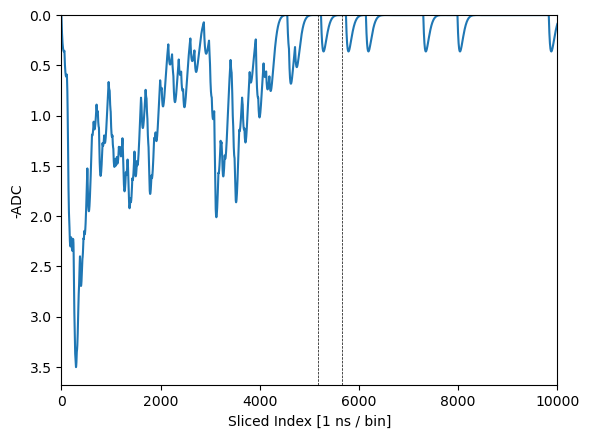

In [148]:
plt.plot(-real_wf_ch0.detach().cpu()[:MAX_BINS])
for i in range(3):
    seg_start = starts_bin[i].item()
    if i + 1 < starts_bin.numel():
        seg_end = starts_bin[i + 1].item()
    else:
        seg_end = MAX_BINS
    if seg_start >= MAX_BINS:
        break
    plt.axvline(seg_start, color="k", linestyle="--", lw=0.5)
plt.axhline(0, color="k", linestyle="--", lw=0.5)
plt.gca().invert_yaxis()
plt.ylim(None, 0)
plt.xlim(0,MAX_BINS)
plt.xlabel(f'Sliced Index [{TICK_NS} ns / bin]')
plt.ylabel('-ADC')
plt.show()


full histogram: 3,329,859 bins (3,329,859 ns)
full conv bins:      3,338,858
stitched conv bins:  3,338,858
max |residual|:      23.803284 ADC
max |residual|/peak: 1.3231 %


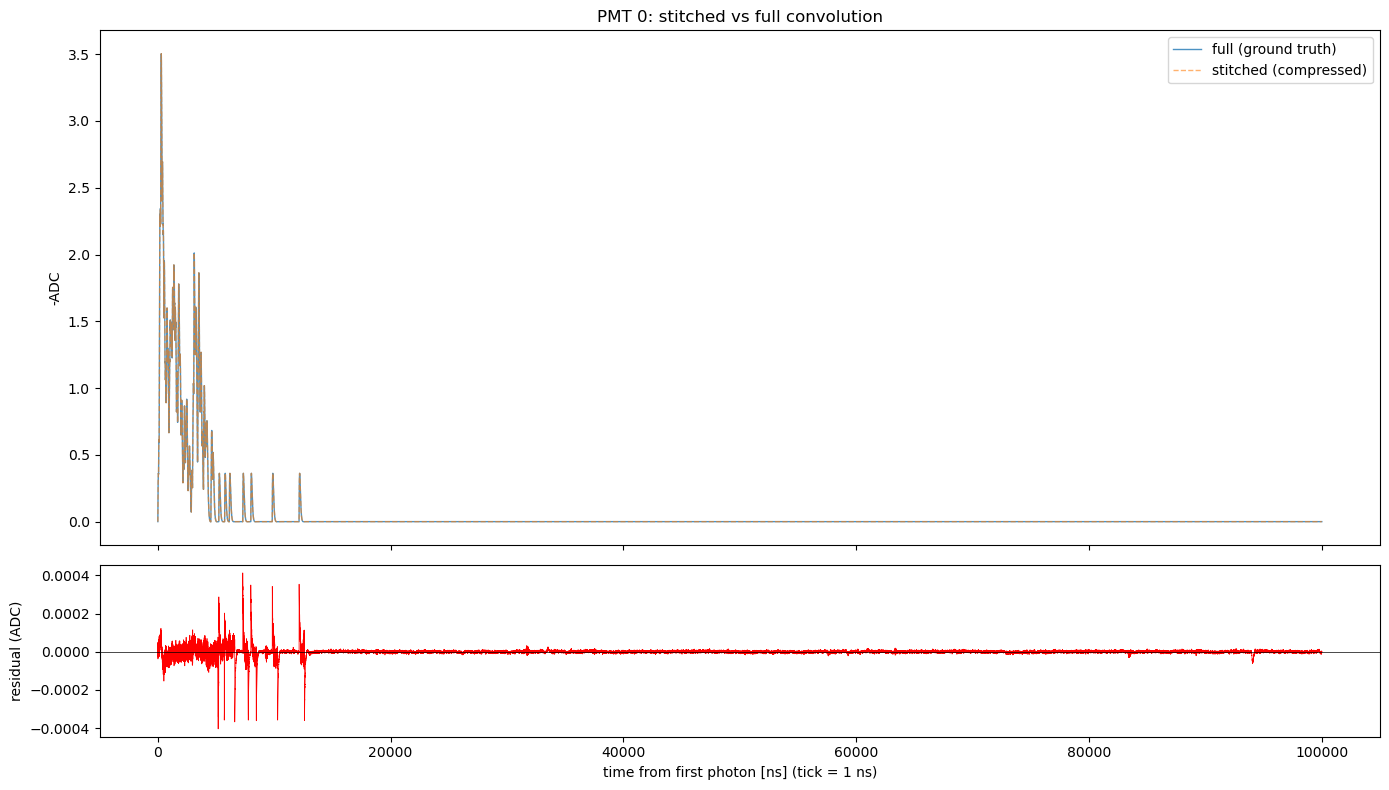

In [145]:
# validation: stitched convolution vs full (naive) convolution for PMT 0
# run on CPU to avoid cuFFT out-of-memory on the huge uncompressed FFT
ch_val = 0
mask_val = (sampler_ch == ch_val)
times_val = sampler_t[mask_val].sort().values.cpu()
kernel_cpu = kernel.cpu()

# full-range histogram on the real time axis (no compression)
t_start = times_val[0]
n_full = int((times_val[-1] - t_start).item() / tick_ns) + 1
idx_full = ((times_val - t_start) / tick_ns).long().clamp(max=n_full - 1)
hist_full = torch.zeros(n_full, dtype=torch.float32)
hist_full.scatter_add_(0, idx_full, torch.ones_like(idx_full, dtype=torch.float32))
print(f"full histogram: {n_full:,} bins ({n_full * tick_ns:,.0f} ns)")

# FFT convolve with the same kernel & gain (CPU)
n_conv_full = n_full + conv_ticks - 1
wf_full = GAIN * torch.fft.irfft(
    torch.fft.rfft(hist_full, n=n_conv_full) * torch.fft.rfft(kernel_cpu, n=n_conv_full),
    n=n_conv_full,
)

# align lengths for comparison
real_wf_cpu = real_wf_ch0.detach().cpu()
n_cmp = min(real_wf_cpu.numel(), wf_full.numel())
residual = real_wf_cpu[:n_cmp] - wf_full[:n_cmp]
peak = wf_full[:n_cmp].abs().max().item()

print(f"full conv bins:      {wf_full.numel():,}")
print(f"stitched conv bins:  {real_wf_cpu.numel():,}")
print(f"max |residual|:      {residual.abs().max().item():.6f} ADC")
print(f"max |residual|/peak: {residual.abs().max().item() / peak * 100:.4f} %")

# overlay plot + residual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
n_show = min(n_cmp, int(MAX_BINS))
x = (torch.arange(n_show).float() * tick_ns).numpy()

ax1.plot(x, -wf_full[:n_show].numpy(), label="full (ground truth)", alpha=0.8, lw=1)
ax1.plot(x, -real_wf_cpu[:n_show].numpy(), label="stitched (compressed)", alpha=0.6, lw=1, ls="--")
ax1.set_ylabel("-ADC")
ax1.legend()
ax1.set_title(f"PMT {ch_val}: stitched vs full convolution")

ax2.plot(x, residual[:n_show].numpy(), color="red", lw=0.5)
ax2.set_ylabel("residual (ADC)")
ax2.set_xlabel(f"time from first photon [ns] (tick = {tick_ns} ns)")
ax2.axhline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()